## Bank Customer Churn Prediction

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

In [1]:
#Installing the libraries with the specified version.
!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.23.5 pandas==1.5.3 -q --user --no-warn-script-location

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xgboost 2.1.1 requires nvidia-nccl-cu12; platform_system == "Linux" and platform_machine != "aarch64", which is not inst

## Importing necessary libraries

In [173]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# library to import to standardize the data
from sklearn.preprocessing import StandardScaler

# importing different functions to build models
import tensorflow as tf
from tensorflow import keras
from keras import backend
from keras.models import Sequential
from keras.layers import Dense, Dropout

# importing SMOTE
from imblearn.over_sampling import SMOTE

# importing metrics
from sklearn.metrics import confusion_matrix,roc_curve,classification_report,recall_score

import random # Module for Ranom funcation.

import time  # Module for time-related operations.

# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [174]:
from google.colab import drive
drive.mount('/content/drive')

pd_bank = pd.read_csv('/content/drive/My Drive/AIML_Class_Files/NeuralNetwork_Capstone/Churn.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

In [175]:
# Spread of Data

pd_bank.head(20)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [176]:
# Shape of Data

pd_bank.shape

(10000, 14)

In [177]:
# Get Info about teh data Set

pd_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Observations
- There are no missing values
- Some of the Attributes need to be Encoded, and Normalized.

In [178]:
# Desribe the data file

pd_bank.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [179]:
# Check for Unique Values for Name

pd_bank.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


### Observation
- There are ~3000 unique Surname.
- But all teh records are having unique CustmerId
- So we dont expect duplicate records.

In [180]:
# Dropping the following Attributes

pd_bank = pd_bank.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
pd_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


### Observations###
- We dropped all three columns
- We can start the EDA to undersyand teh relatonship of various attributes.

## Exploratory Data Analysis

### Univariate Analysis

In [181]:
# Utiity Function to boxplot & Histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [182]:
# Utility Funcation for Labeled Barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

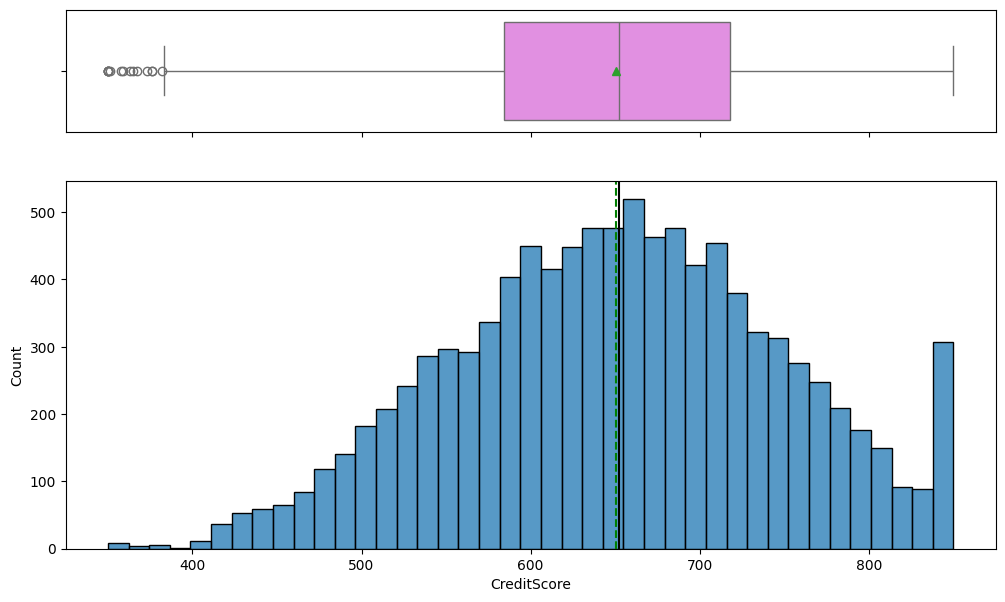

In [183]:
# Plot the Variation of 'CreditScore'
histogram_boxplot(pd_bank, 'CreditScore')

### Observation ###
- Distribution is Normal and Even, since Mean & Median are almst the same
- There are some outlier at the lower-end.
- Currently we might leave it like that and dont remove those rows.  

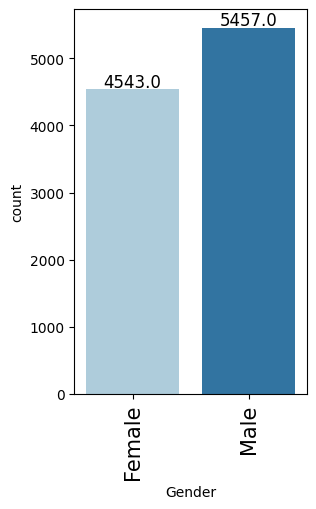

In [184]:
# Plot the Variation of 'Gender'

labeled_barplot(pd_bank,'Gender')

### Observations ###
- Male & Female are Evenly distributed.

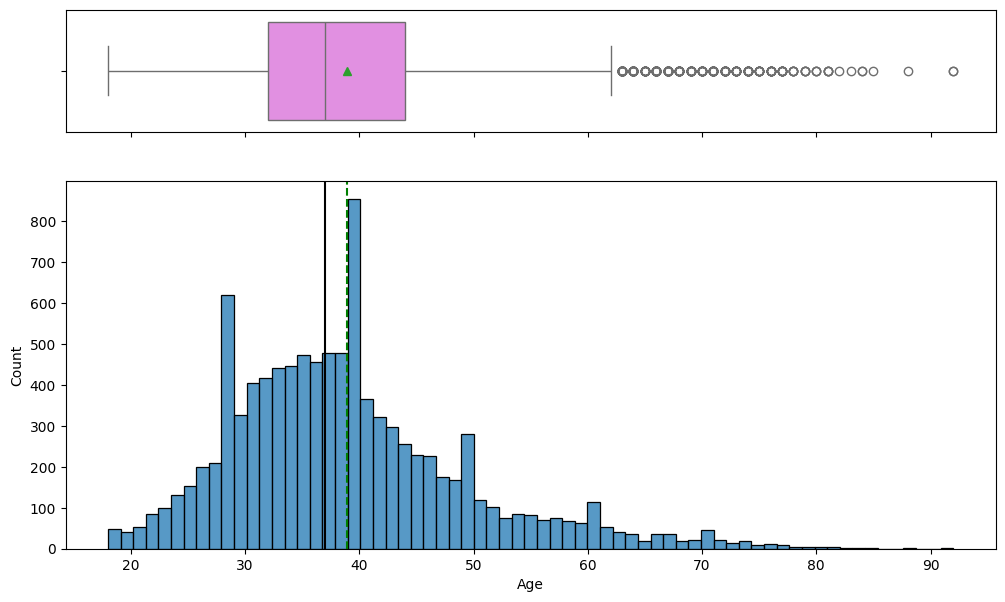

In [185]:
# Plot the Variation of 'Age'

histogram_boxplot(pd_bank, 'Age')

### Observtions ###
- Distrbutions are almost Even, partially right skewed.
- There are outliers from teh age of ~63.
- We will see if this need to be treated or removed.
- Removong Rows can hve adverse affect on other columns.



In [186]:
# Find Customers with 'Age' > 65

pd_bank[pd_bank['Age'] > 65]['Age'].count()

264

### Observations ###
- Number of Customer that are more than 65 are around 265 out fo 10000.
- For now we will keep it, since the numbers are small.

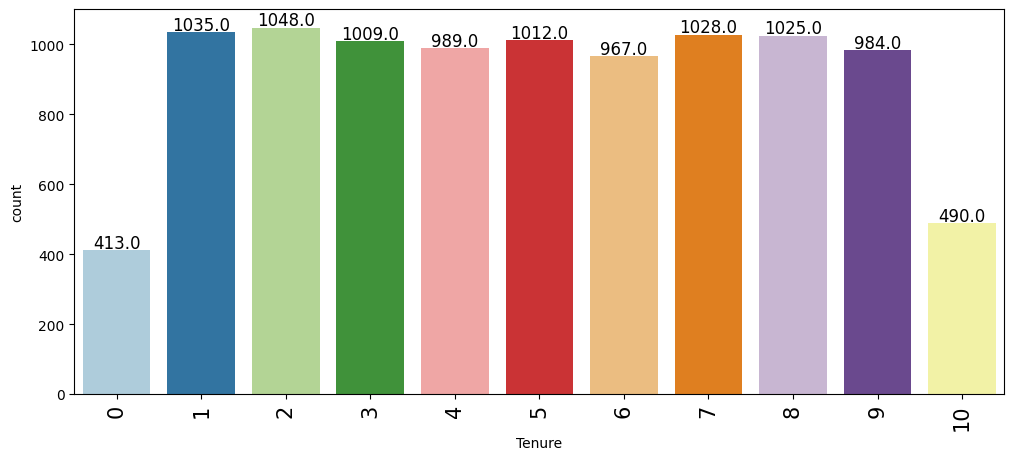

In [187]:
# Plot the Variation of 'Tenure'

labeled_barplot(pd_bank, 'Tenure')

### Observations ###
- New Customers and Longest Tenure Customers are the smallest of the lot.
- This tells that especially the Longst Tenured Customers could be leaving over time.
- We will get better picture once we map the relation-ship between Tenure and Numnber of Exists.

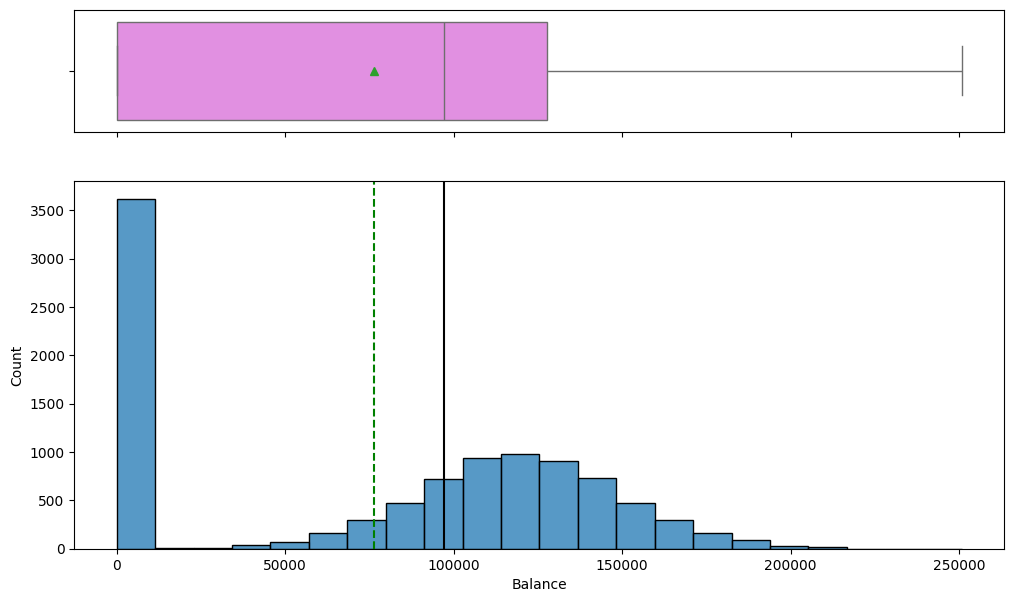

In [188]:
# Plot the Variation of 'Balance'

histogram_boxplot(pd_bank, 'Balance')

### Observations ###
- One third of the Custoemrs are having Balance around 10000
- We dont consider this an Outlier.
- In the NeuralNetwork calculation we cannormalize this this attributes.
- Rest of the Balance data points are evently distributed.
- We will see how the Salary pans out in the range of 10,000 to 50,000 since the customrs are having 0 balance.
- We can impute ths data, but snce it is individual balance of Customer, doing so might not be right

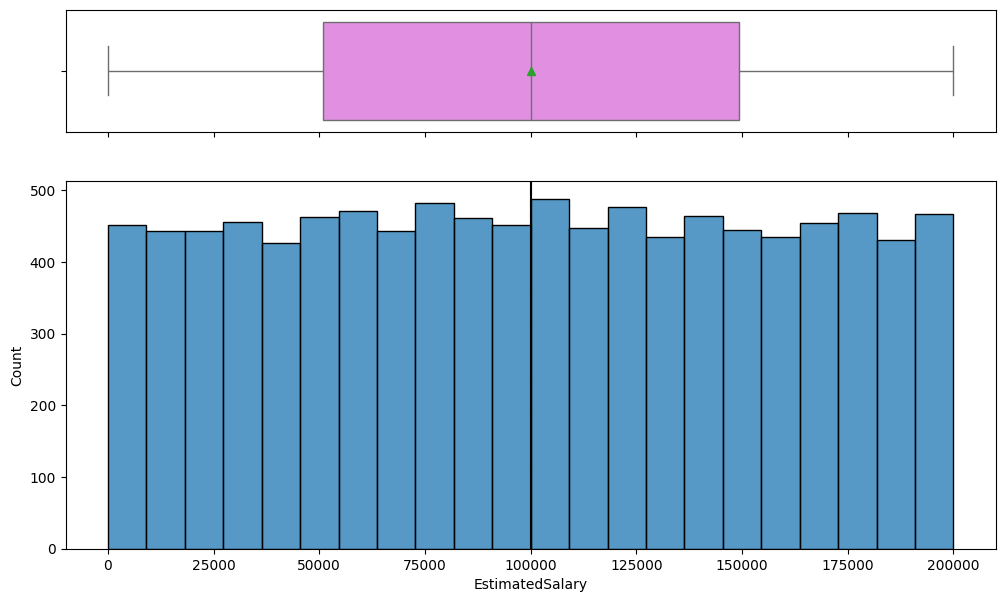

In [189]:
# Plot the Variation of 'EstimatedSalary'

histogram_boxplot(pd_bank, 'EstimatedSalary')

### Observation ###
- All Customers are spread evenly across a wide saary Range.
- Customers having Zero Balance, lookng at the Salary plot is in range of Low Income or Very high Incoem Group.

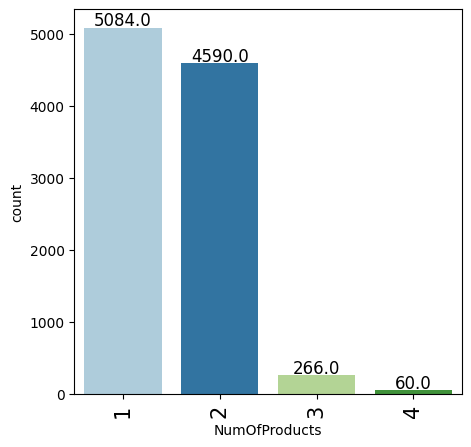

In [190]:
# Plot the Variation of 'NumOfProducts'

labeled_barplot(pd_bank, 'NumOfProducts')

### Observations ###
- 90% of the Customers have between 1 & 2 Products which is a healthy sigen for the bank.

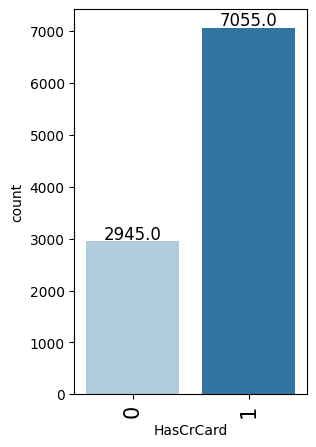

In [191]:
# Plot the Variation of 'HasCrCard'

labeled_barplot(pd_bank, 'HasCrCard')

### Observations ###
- 2/3rd of the Customers have 1 Credit Cards, whoch is a

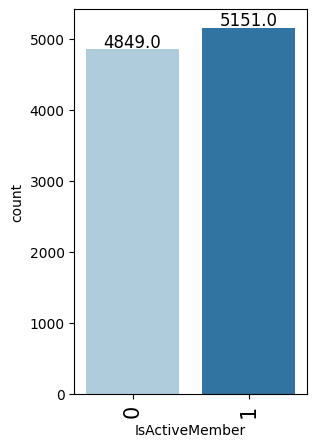

In [192]:
# Plot the Variation of 'IsActiveMember'

labeled_barplot(pd_bank, 'IsActiveMember')

### Observations ###
- We see that Active / Not Active is evently split.
- This tell that there are dorment customers.

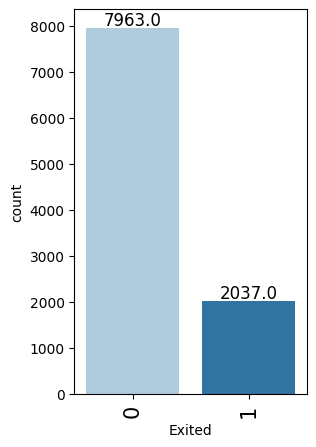

In [193]:
# Plot the Variation of 'Exited'

labeled_barplot(pd_bank, 'Exited')

### Observations ###
- Customers show are staying back are majority ~8000.
- This is a healthy sign for the bank since exist are only 1/5th.
- We need find out what attributes are correlating to this ~2000 odd exists.

### Bivariate Analysis

In [194]:
# Utility Function for Bi-Variate Analysis

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [195]:
# Impute 'Gender' Category with Binary Value
# Male = 1, Female = 0

pd_bank['Gender'].replace({'Male': 1, 'Female': 0}, inplace=True)

# Convert Geography to OneHot Encoded Value
pd_bank = pd.get_dummies(pd_bank, columns=['Geography'], dtype='int64')


In [196]:
pd_bank.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

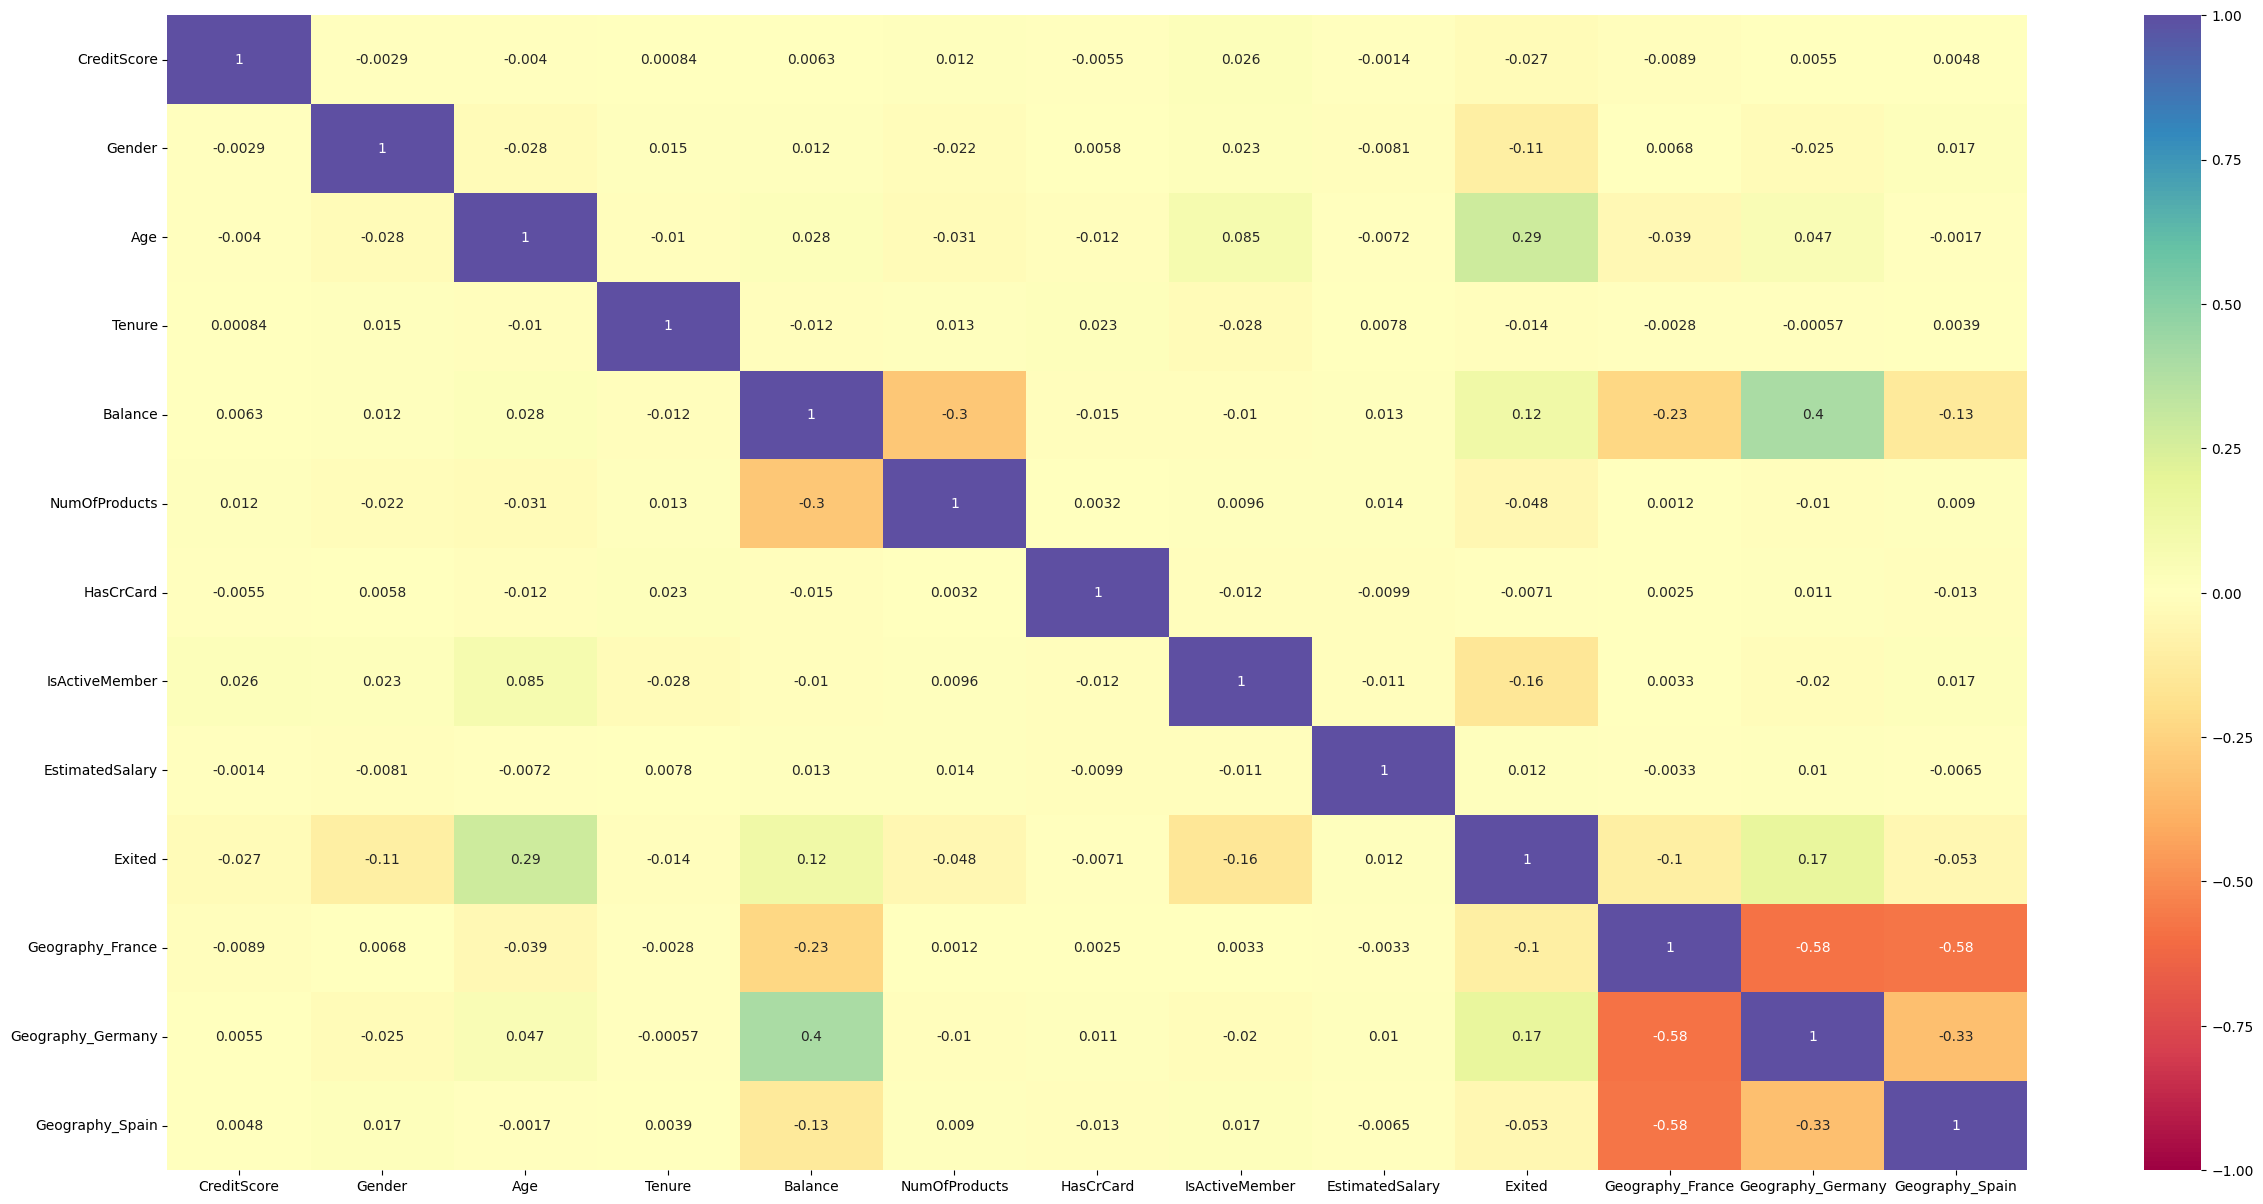

In [197]:
# Lets build a heatmap of Correlation

plt.figure(figsize=(30, 15))
sns.heatmap(data=pd_bank.corr(), vmin=-1, vmax=1, cbar=True, annot=True, cmap="Spectral")
plt.show();

### Observations ###

- There is strong positive correlation for
  - Age, Balance, Estimated Salary, German Geography.
- We will see next how some of these pan out.

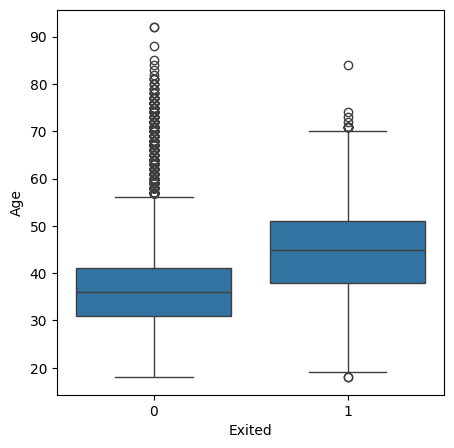

In [198]:
plt.figure(figsize=(5,5))
sns.boxplot(data=pd_bank, x='Exited', y='Age')
plt.show()

### Observation ###
- It is observed that Higher Age ad at lower Age Exists are less.
- It is in 40s, 50, 60s there is larger Exists.

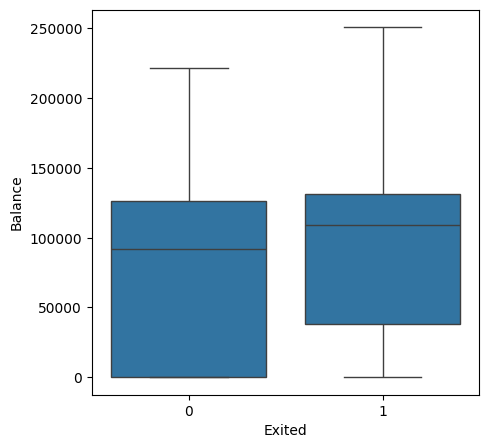

In [199]:
# BoxPlot for Exited Vs Age

plt.figure(figsize=(5,5))
sns.boxplot(data=pd_bank, x='Exited', y='Balance')
plt.show()

### Observation ###
- It is observed that at the Balance range of 100,000 more people are existinf
- Lower Balance or at hogher Balance range the Exists are less.

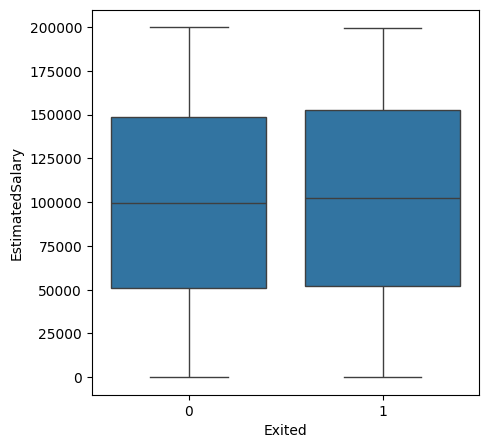

In [200]:
# BoxPlot for Exited Vs Age

plt.figure(figsize=(5,5))
sns.boxplot(data=pd_bank, x='Exited', y='EstimatedSalary')
plt.show()

### Observation ###
- There is an even distribution of people leaving and staying withthe bank at the mean Slry range of 100,000
- This churn could be attributed to teh fact that as earning power increases people might be tryignt our otehr financial avenues and products.  

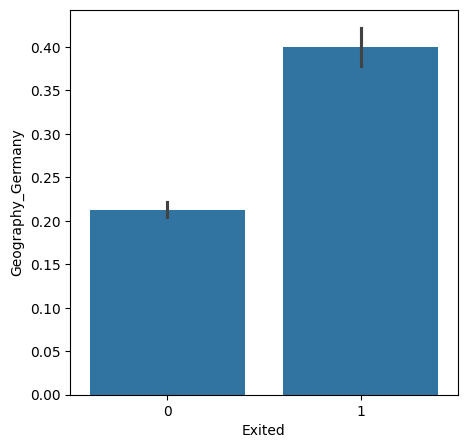

In [201]:
# BoxPlot for Exited Vs Geography

plt.figure(figsize=(5,5))
sns.barplot(data=pd_bank, x='Exited', y='Geography_Germany')
plt.show()


### Observation ###
- Majority numbers are from Germany who has move out.
- This explains why they have strong correlation

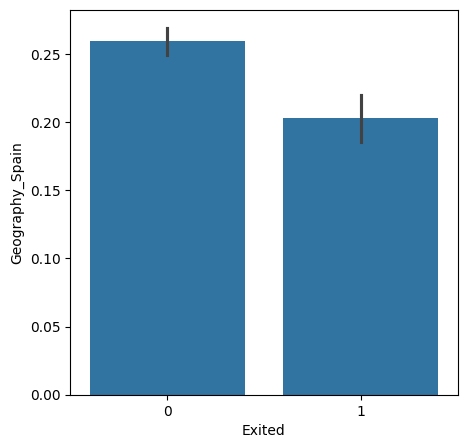

In [202]:
# BoxPlot for Exited Vs Geography_Germany

plt.figure(figsize=(5,5))
sns.barplot(data=pd_bank, x='Exited', y='Geography_Spain')
plt.show()

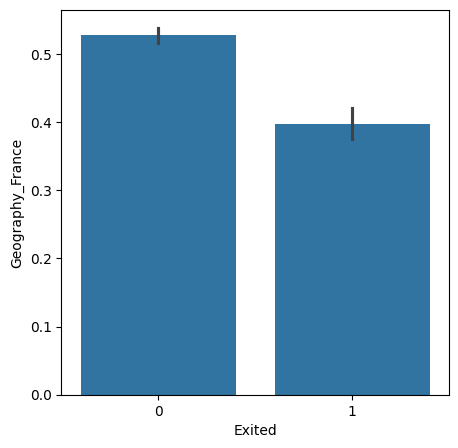

In [203]:
plt.figure(figsize=(5,5))
sns.barplot(data=pd_bank, x='Exited', y='Geography_France')
plt.show()

### Observations ###
- Majoriy in Spain and France are reaining with the bank.
- This also explians why both are hvign weak correlation.

## Data Preprocessing

### Dummy Variable Creation

In [204]:
# Creating a copy of the back Dataframe for future restoration.
pd_bank1 = pd_bank.copy()

### Train-validation-test Split

In [205]:
# Creating X &  Variables

y = pd_bank1['Exited']
X = pd_bank1.drop(['Exited'], axis=1)

X_temp, X_eval, y_temp, y_eval = train_test_split(X, y, train_size=0.8, random_state=1, stratify=y, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, train_size=0.7, random_state=1, shuffle=True)

y_train.value_counts()


,count
Exited,
0,4442
1,1158


### Observations ###
- Split first set to Temp & Eval DFs
- Next Split Temp DF to Train & Test DFs

In [206]:
# Print the Shapes of Train, Test & Eval

print(X_train.shape)
print(X_test.shape)
print(X_eval.shape)

print(y_train.shape)
print(y_test.shape)
print(y_eval.shape)

(5600, 12)
(2400, 12)
(2000, 12)
(5600,)
(2400,)
(2000,)


### Data Normalization

In [207]:
# Normalizing Columns to a common Scale.

std_scalar = StandardScaler()

cols_list = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']

X_train[cols_list] = std_scalar.fit_transform(X_train[cols_list])
X_test[cols_list] = std_scalar.transform(X_test[cols_list])
X_eval[cols_list] = std_scalar.transform(X_eval[cols_list])


In [208]:
X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
8977,-0.188789,0,-0.752301,-1.029129,0.186681,0.80278,1,0,0.499005,0,0,1
7827,-0.459194,1,0.191869,1.713093,-1.217321,0.80278,0,1,-0.032750,1,0,0
1780,1.589640,1,-0.563467,1.027537,-1.217321,0.80278,1,0,0.780028,1,0,0
998,1.683242,0,-1.035551,-0.343573,1.453966,0.80278,1,1,-1.559072,0,1,0
3338,0.404021,0,-1.413219,-0.686351,-1.217321,0.80278,1,1,0.054345,0,0,1


In [209]:
X_test.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
768,0.362420,1,0.191869,-1.029129,0.690252,0.802780,0,0,0.370580,0,0,1
7938,1.620841,1,0.003035,-1.029129,-1.217321,-0.911123,0,0,1.181131,1,0,0
8020,2.088849,0,0.663953,-1.029129,1.296751,-0.911123,1,1,-1.400291,1,0,0
2113,0.924029,1,-0.374633,0.341982,0.402994,-0.911123,0,0,-0.243014,0,1,0
3911,1.381637,0,-0.374633,-0.343573,-1.217321,-0.911123,1,1,0.358005,1,0,0


In [210]:
X_eval.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
4466,-2.456027,1,-0.374633,-1.029129,-1.217321,0.802780,1,1,-0.666292,0,0,1
3754,-1.187206,1,-0.374633,1.027537,0.677627,-0.911123,1,1,0.637212,0,0,1
9601,0.102416,0,-0.563467,0.684760,0.214992,-0.911123,1,0,0.654753,1,0,0
9758,-0.968802,0,0.380702,-0.343573,0.787524,-0.911123,1,1,-0.423608,0,1,0
8577,1.090432,1,2.457875,-1.371907,0.951486,-0.911123,1,1,0.392344,0,1,0


### Observations ###
- We Split the Total test data into three categories
  - X_train, X_test, X_eval
- Then we Normalized / Scaled following columns.
  - 'CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary'

## Model Building

### Model Evaluation Criterion

1. Find influencing Attributes that helps Customer Retention / of reduce Exits.

2. Confusion Metrics
  - TP = Existing Leaves (Predict) / Customer Leaves (Actual)
  - FP = Customer Leaves (Predict) / Customer DONOT Leave (Actual)
  - FN = Customer DONOT Leave (Predict) / Customer Leave (Actual)
  - TN = Customer DONOT Leave (Predict) / Customer DONOT Leave (Actual)

3. Success Criteria =
  - Improve 'Precision' by reducing FP. This is bonus since we predict the Customer to Leave but he stays.
  - Improving 'Recall'  by reducting FN since. Reducing FN is more important with our model since if we predict wrong cost to bank is more.
    - Both these scenarios are benificial to bank.

4. We will target to 'Recall' metrix to see what model help to Maximise it.
5. We shoudl also as part of NN train / test ensire that the measure of Loss is also optimal and avoif model that Overfit or Underfit.

### Model Building Assumptions ###
- Since we have lot of Optimization option for Neural Network, we will standarize some of the Evaluation Parameters.
  - Epoch = 50
  - Batch Size = 32
  - Neural Network Layers
    - 1 Input Layer of 12 Nodes
    - 2 Hidden Layer
      - Layer 1: 64; activation='relu'
      - Layer 2: 32; activation='tanh'
    - 1 Output Layer
      - 1 Node - Since it is binary output; activation='sigmoid'
  - Learning Rate = 0.001


In [211]:
#Converting to Train, Test, Eval  to Array of values

X_train1 = X_train.to_numpy()
X_test1 = X_test.to_numpy()
X_eval1 = X_eval.to_numpy()

y_train1 = y_train.to_numpy()
y_test1 = y_test.to_numpy()
y_eval1 = y_eval.to_numpy()

In [212]:
X_train1 #  Example - Array format for X_train

array([[-0.18878915,  0.        , -0.7523005 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.45919365,  1.        ,  0.19186866, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.5896405 ,  1.        , -0.56346667, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.42482108,  1.        , -0.7523005 , ...,  0.        ,
         1.        ,  0.        ],
       [-0.35519192,  0.        ,  2.08020699, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.83042784,  0.        , -0.46904975, ...,  0.        ,
         0.        ,  1.        ]])

In [213]:
y_train1 #  Example - Array format for y_train1

array([0, 0, 0, ..., 0, 1, 0])

In [214]:
# Create Utility Funcation for Neural Network Visualization

def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [215]:
# Create DataFrame to store teh result
# Defining the columns of the dataframe which are nothing but the hyper parameters and the metrics.

columns = ["# hidden layers","# neurons - hidden layer","activation function - hidden layer ","# epochs","batch size","optimizer","learning rate, momentum","weight initializer","regularization","train loss","validation loss","train recall","validation recall","time (secs)"]

#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

In [216]:
# Initializing the Calculations for Neural Network

num_classes = 1        # Output Binary Class
lrn_rate = 0.001       # learning Rate.
batch_size = 32
epochs = 50


# Set the seed using keras.utils.set_random_seed.
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(2)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

### Neural Network with SGD Optimizer

In [217]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

# init Neural network
nn_model_1 = Sequential()

nn_model_1.add(Dense(32, activation="relu", input_dim=X_train1.shape[1]))           # Fist Hidden Layer - 64
nn_model_1.add(Dense(64,activation="tanh"))                                        # Second Hidden Layer - 32
nn_model_1.add(Dense(num_classes, activation='sigmoid'))  # Output Layer           # Output Layer - 1

# Summary for Model
nn_model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [218]:
optimizer = keras.optimizers.SGD(learning_rate=lrn_rate)  # Optimizer with learning Rate.
nn_model_1.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), optimizer=optimizer, metrics=["recall"])

# Training / Model Fit
start_time = time.time()
nn_model_train = nn_model_1.fit(X_train1, y_train1, validation_data=(X_test1, y_test1), batch_size=batch_size, epochs=epochs)
end_time = time.time()

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6668 - recall: 0.3373 - val_loss: 0.6026 - val_recall: 0.1589
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6002 - recall: 0.1255 - val_loss: 0.5563 - val_recall: 0.0297
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5631 - recall: 0.0216 - val_loss: 0.5286 - val_recall: 0.0042
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5412 - recall: 2.3357e-04 - val_loss: 0.5111 - val_recall: 0.0042
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5274 - recall: 2.3357e-04 - val_loss: 0.4992 - val_recall: 0.0021
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5180 - recall: 2.3357e-04 - val_loss: 0.4907 - val_recall: 0.0021
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5113 - recall: 7.2736e-04 - val_loss: 0.4842 - val_recall: 0.0021
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5061 - recall: 7.2736e-04 - val_loss: 0.4789 - val_rec

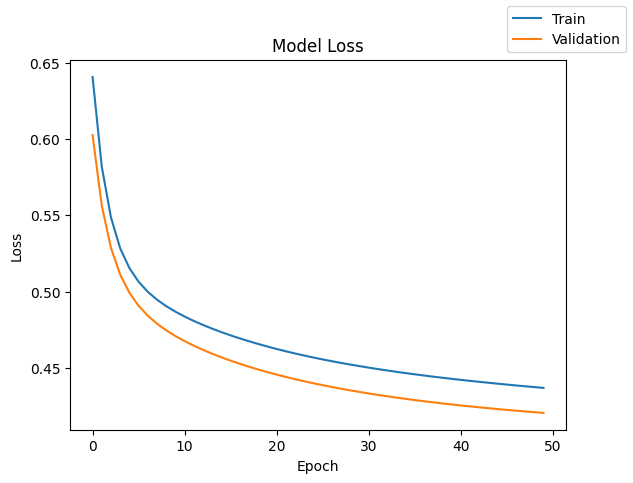

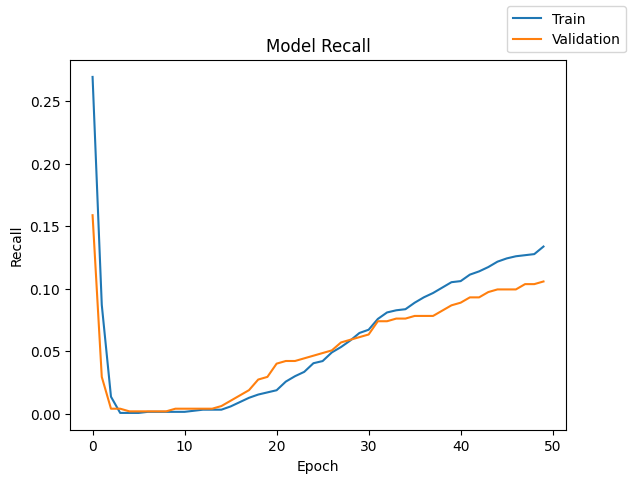

In [219]:
# Plot Training & Validation - Accuracy & Loss

plot(nn_model_train,'loss')
plot(nn_model_train,'recall')

In [220]:
results.loc[0] = [2,[32, 64],['relu', 'tanh'],50,32,"sgd",[0.001, "-"],"xavier","-",nn_model_train.history["loss"][-1],nn_model_train.history["val_loss"][-1],nn_model_train.history["recall"][-1],nn_model_train.history["val_recall"][-1],round(end_time - start_time,2)]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.43682,0.420412,0.133851,0.105932,35.84


### Observations ###
- Loss funcation gradient was smooth, tending towards convrgance.
- Validation loss was less that Training loss.
- From the plot we undertand that Recall has improved steadly, after the initial drop for both Training & Validation.
- Recall Value for Both Training & Validation is very low.
- We will see how Optimizing & Tuning the model will help next.


## Model Performance Improvement

### Neural Network with Adam Optimizer

In [221]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

# init Neural network
nn_model_2 = Sequential()

nn_model_2.add(Dense(32, activation="relu", input_dim=X_train1.shape[1]))           # Fist Hidden Layer - 64
nn_model_2.add(Dense(64,activation="tanh"))                                        # Second Hidden Layer - 32
nn_model_2.add(Dense(num_classes, activation='sigmoid'))  # Output Layer           # Output Layer - 1

# Summary for Model
nn_model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [222]:
optimizer = keras.optimizers.Adam(learning_rate=lrn_rate)  # Optimizer with learning Rate.
nn_model_2.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), optimizer=optimizer, metrics=["recall"])

# Training / Model Fit
start_time = time.time()
nn_model_train = nn_model_2.fit(X_train1, y_train1, validation_data=(X_test1, y_test1), batch_size=batch_size, epochs=epochs)
end_time = time.time()

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5465 - recall: 0.1311 - val_loss: 0.4066 - val_recall: 0.1907
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4219 - recall: 0.2406 - val_loss: 0.3750 - val_recall: 0.3390
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3882 - recall: 0.3700 - val_loss: 0.3554 - val_recall: 0.4513
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3698 - recall: 0.4421 - val_loss: 0.3466 - val_recall: 0.4958
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3632 - recall: 0.4609 - val_loss: 0.3422 - val_recall: 0.5085
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3601 - recall: 0.4741 - val_loss: 0.3395 - val_recall: 0.5169
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3578 - recall: 0.4831 - val_loss: 0.3376 - val_recall: 0.5064
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3558 - recall: 0.4842 - val_loss: 0.3357 - val_recall: 0.5169
Epoch 9/

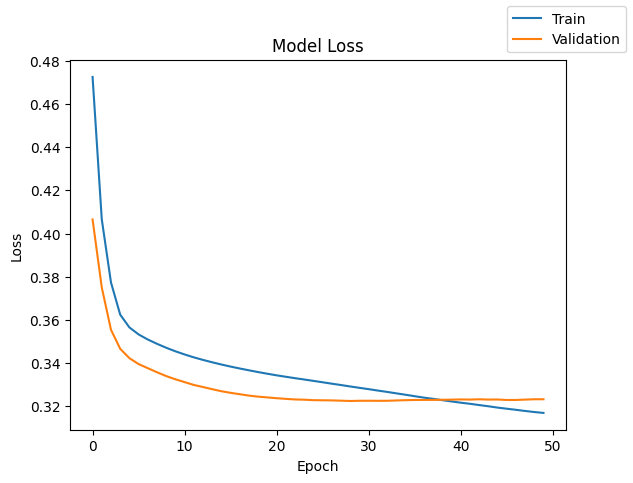

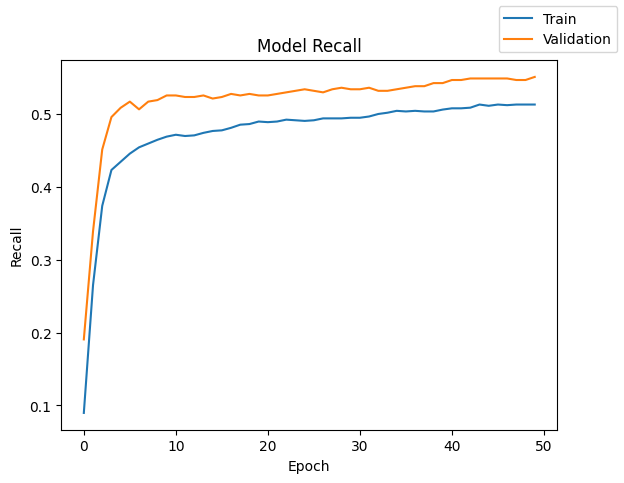

In [223]:
# Plot Training & Validation - Recall & Loss

plot(nn_model_train,'loss')
plot(nn_model_train,'recall')

In [224]:
results.loc[1] = [2,[32, 64],['relu', 'tanh'],50,32,"adam",[0.001, "-"],"xavier","-",nn_model_train.history["loss"][-1],nn_model_train.history["val_loss"][-1],nn_model_train.history["recall"][-1],nn_model_train.history["val_recall"][-1],round(end_time - start_time,2)]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.436820,0.420412,0.133851,0.105932,35.84
1,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,-,0.316814,0.323157,0.512953,0.550847,38.33


### Observations ###
- Loss funcation did reach convergence between Trainin and Testing.
- Recall has improved significantly.
- Recall tends to  show higher than trainin but the trend seems to go towards a convergence point.


### Neural Network with Adam Optimizer and Dropout

In [225]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

# init Neural network
nn_model_3 = Sequential()

nn_model_3.add(Dense(32, activation="relu", input_dim=X_train1.shape[1]))           # Fist Hidden Layer - 64
nn_model_3.add(Dropout(0.3))                                                        # Drop out rate 0.3
nn_model_3.add(Dense(64,activation="tanh"))                                         # Second Hidden Layer - 32
nn_model_3.add(Dropout(0.3))                                                        # Drop out rate 0.2
nn_model_3.add(Dense(num_classes, activation='sigmoid'))  # Output Layer            # Output Layer - 1

# Summary for Model
nn_model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
optimizer = keras.optimizers.Adam(learning_rate=lrn_rate)  # Optimizer with learning Rate.
nn_model_3.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), optimizer=optimizer, metrics=["recall"])

# Training / Model Fit
start_time = time.time()
nn_model_train = nn_model_3.fit(X_train1, y_train1, validation_data=(X_test1, y_test1), batch_size=batch_size, epochs=epochs)
end_time = time.time()

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5570 - recall: 0.1691 - val_loss: 0.4228 - val_recall: 0.0805
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4659 - recall: 0.1642 - val_loss: 0.3991 - val_recall: 0.1504
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4518 - recall: 0.2079 - val_loss: 0.3861 - val_recall: 0.2076
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4281 - recall: 0.2827 - val_loss: 0.3713 - val_recall: 0.2648
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4136 - recall: 0.3508 - val_loss: 0.3592 - val_recall: 0.2987
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4097 - recall: 0.3554 - val_loss: 0.3537 - val_recall: 0.3114
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4131 - recall: 0.3421 - val_loss: 0.3483 - val_recall: 0.3475
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3984 - recall: 0.3879 - val_loss: 0.3447 - val_recall: 0.3453
Epoch 9/

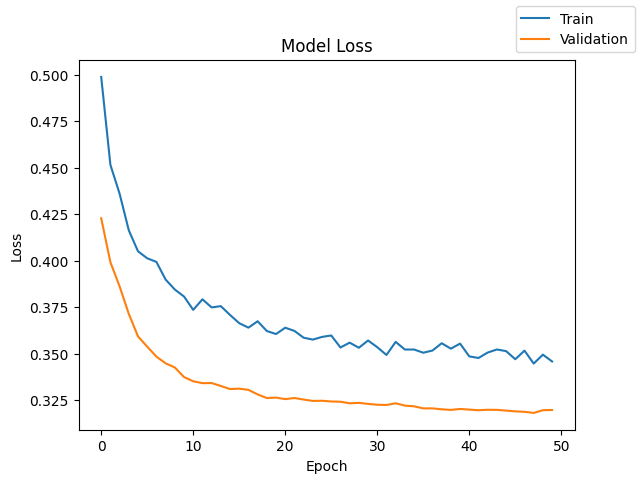

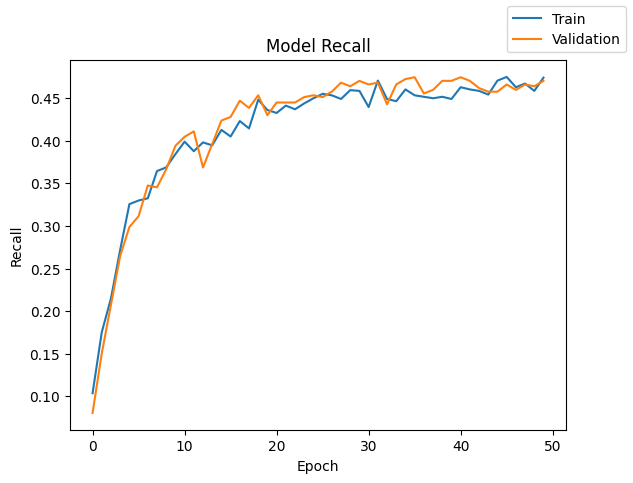

In [227]:
# Plot Training & Validation - Recall & Loss

plot(nn_model_train,'loss')
plot(nn_model_train,'recall')

In [228]:
results.loc[2] = [2,[32, 64],['relu', 'tanh'],50,32,"adam",[0.001, "-"],"xavier","dropout (0.3)",nn_model_train.history["loss"][-1],nn_model_train.history["val_loss"][-1],nn_model_train.history["recall"][-1],nn_model_train.history["val_recall"][-1],round(end_time - start_time,2)]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.436820,0.420412,0.133851,0.105932,35.84
1,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,-,0.316814,0.323157,0.512953,0.550847,38.33
2,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,dropout (0.3),0.345733,0.319666,0.474093,0.470339,36.53


### Observations ###
- We used multiple Dropout Rate - 0.2, 0.3 and teh resulst were very similar.
- Validation Loss was always less than Training, with Loss tending toward convergance.
- The Loss Funcation gradient changes were 'choppy' due to node drop-outs.
- Recall decreased with Adam + Dropout model,
- Change in Gradients were 'choppy' between Training & Testing Recall
- Recall was converging right from Epoch 5. but due to node dropout the convergence was oscellating between UnderFitting & Overfitting modes on Training and Validation values.
- We will park this model for considration.

### Calculating SMOTE to Training Data

In [229]:
# Applying SMOTE on Train Data
sm = SMOTE(random_state=1)

X_train1_smote, y_train1_smote = sm.fit_resample(X_train1, y_train1)

print("X_train1 Original Sampling:", X_train1.shape)
print("y_train1 Original Sampling:", y_train1.shape)

print("X_train1 Up-Sampling:", X_train1_smote.shape)
print("t_train1 Up-Sampling:", y_train1_smote.shape)


X_train1 Original Sampling: (5600, 12)
y_train1 Original Sampling: (5600,)
X_train1 Up-Sampling: (8884, 12)
t_train1 Up-Sampling: (8884,)


### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

In [230]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

# init Neural network
nn_model_4 = Sequential()

nn_model_4.add(Dense(32, activation="relu", input_dim=X_train1_smote.shape[1]))           # Fist Hidden Layer - 32 with SMOTE Up-sampled data
nn_model_4.add(Dense(64,activation="tanh"))                                               # Second Hidden Layer - 64
nn_model_4.add(Dense(num_classes, activation='sigmoid'))  # Output Layer                  # Output Layer - 1

# Summary for Model
nn_model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [231]:
optimizer = keras.optimizers.SGD(learning_rate=lrn_rate)  # Optimizer with learning Rate.
nn_model_4.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), optimizer=optimizer, metrics=["recall"])

# Training / Model Fit
start_time = time.time()
nn_model_train = nn_model_4.fit(X_train1_smote, y_train1_smote, validation_data=(X_test1, y_test1), batch_size=batch_size, epochs=epochs)
end_time = time.time()

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7013 - recall: 0.3179 - val_loss: 0.6659 - val_recall: 0.4725
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6804 - recall: 0.4586 - val_loss: 0.6631 - val_recall: 0.5890
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6646 - recall: 0.5635 - val_loss: 0.6566 - val_recall: 0.6653
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6518 - recall: 0.6244 - val_loss: 0.6488 - val_recall: 0.6780
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6409 - recall: 0.6503 - val_loss: 0.6407 - val_recall: 0.6886
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6315 - recall: 0.6635 - val_loss: 0.6330 - val_recall: 0.6928
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6233 - recall: 0.6711 - val_loss: 0.6259 - val_recall: 0.6970
Epoch 8/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6160 - recall: 0.6769 - val_loss: 0.6194 - val_recall: 0.6970
Epoch 9/

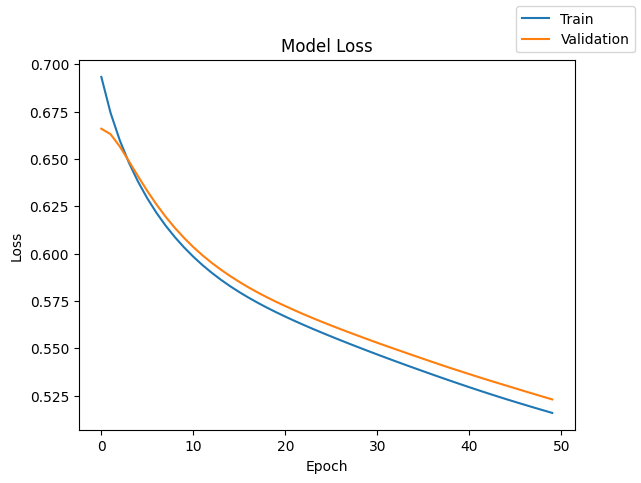

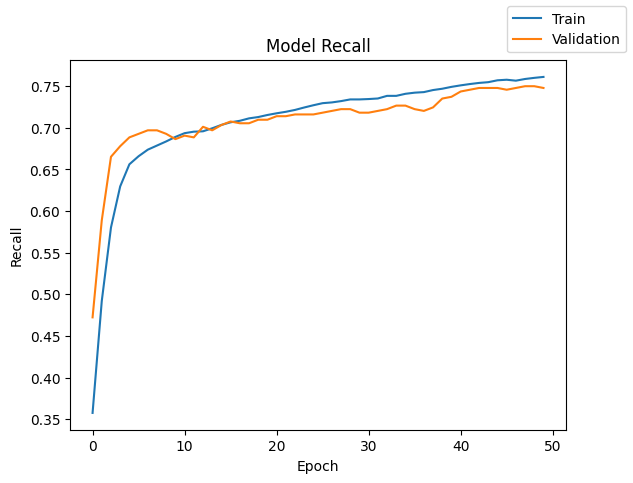

In [232]:
# Plot Training & Validation - Recall & Loss

plot(nn_model_train,'loss')
plot(nn_model_train,'recall')

In [233]:
results.loc[3] = [2,[32, 64],['relu', 'tanh'],50,32,"sgd",[0.001, "-"],"xavier","smote",nn_model_train.history["loss"][-1],nn_model_train.history["val_loss"][-1],nn_model_train.history["recall"][-1],nn_model_train.history["val_recall"][-1],round(end_time - start_time,2)]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.436820,0.420412,0.133851,0.105932,35.84
1,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,-,0.316814,0.323157,0.512953,0.550847,38.33
2,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,dropout (0.3),0.345733,0.319666,0.474093,0.470339,36.53
3,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,smote,0.515850,0.522986,0.761144,0.747881,56.51


### Observations ###
- With SMOTE there is much better convergance.
- Convergance happend early with SMOTE for loss function between Epoch 3 - 6
- Validation Loss is slightly higher compared to Training loss whoch says it is trending to over fitting
- On teh REcall side there wa convergance aroing Epoch 40.
- Recall Value with SNOTE for both Training & Validation is much higher than previous model.
- Recall value for Validation flow stands at 0.74.
- This Model will defintly be considered since the Loss Function & Recall Gradient are much smoother, whch says that all nodes are equally participating in the convergance process.  

### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

In [234]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

# init Neural network
nn_model_5 = Sequential()

nn_model_5.add(Dense(32, activation="relu", input_dim=X_train1_smote.shape[1]))           # Fist Hidden Layer - 32
nn_model_5.add(Dense(64,activation="tanh"))                                         # Second Hidden Layer - 64
nn_model_5.add(Dense(num_classes, activation='sigmoid'))                            # Output Layer - 1

# Summary for Model
nn_model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [235]:
optimizer = keras.optimizers.Adam(learning_rate=lrn_rate)  # Optimizer with learning Rate.
nn_model_5.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), optimizer=optimizer, metrics=["recall"])

# Training / Model Fit
start_time = time.time()
nn_model_train = nn_model_5.fit(X_train1_smote, y_train1_smote, validation_data=(X_test1, y_test1), batch_size=batch_size, epochs=epochs)
end_time = time.time()

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.6123 - recall: 0.6578 - val_loss: 0.5143 - val_recall: 0.7564
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4909 - recall: 0.7789 - val_loss: 0.4836 - val_recall: 0.7818
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4633 - recall: 0.7963 - val_loss: 0.4736 - val_recall: 0.7903
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4544 - recall: 0.7983 - val_loss: 0.4674 - val_recall: 0.7818
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4482 - recall: 0.7939 - val_loss: 0.4630 - val_recall: 0.7839
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4433 - recall: 0.7934 - val_loss: 0.4601 - val_recall: 0.7860
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4388 - recall: 0.7968 - val_loss: 0.4583 - val_recall: 0.7818
Epoch 8/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4345 - recall: 0.7959 - val_loss: 0.4555 - val_recall: 0.7712
Epoch 9/

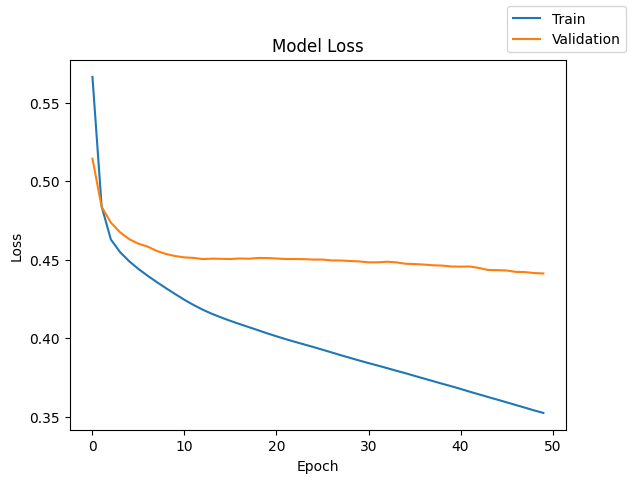

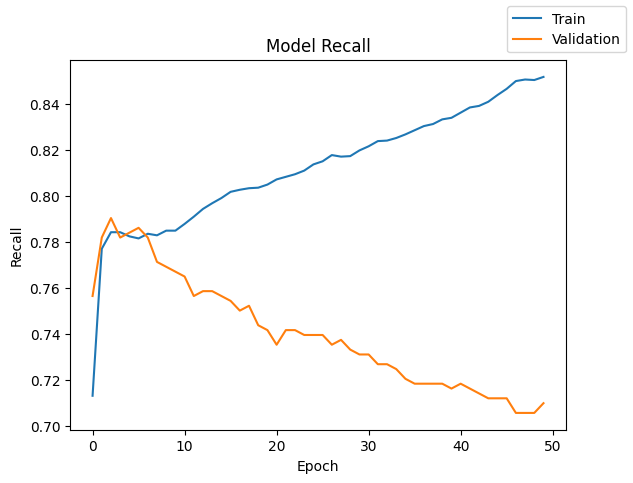

In [236]:
# Plot Training & Validation - Recall & Loss

plot(nn_model_train,'loss')
plot(nn_model_train,'recall')

In [237]:
results.loc[4] = [2,[32, 64],['relu', 'tanh'],50,32,"adam",[0.001, "-"],"xavier","smote",nn_model_train.history["loss"][-1],nn_model_train.history["val_loss"][-1],nn_model_train.history["recall"][-1],nn_model_train.history["val_recall"][-1],round(end_time - start_time,2)]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.436820,0.420412,0.133851,0.105932,35.84
1,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,-,0.316814,0.323157,0.512953,0.550847,38.33
2,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,dropout (0.3),0.345733,0.319666,0.474093,0.470339,36.53
3,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,smote,0.515850,0.522986,0.761144,0.747881,56.51
4,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,smote,0.352372,0.441176,0.851643,0.709746,63.09


### Observations ###
- This model both Loss function and Recall achiee convergance very early in Train & Validation.
- But quickly both the data points start to diverge and a steap gradient as if there is no reltionship between Training & Validation datasets.
- Recall  value drops compared to Training data and is also less than previous SGD - SMOTE model
- This Model we will not consider in our selection process.  

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

In [238]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

# init Neural network
nn_model_6 = Sequential()

nn_model_6.add(Dense(32, activation="relu", input_dim=X_train1_smote.shape[1]))           # Fist Hidden Layer - 32
nn_model_6.add(Dropout(0.3))                                                              # Dropout of 0.3
nn_model_6.add(Dense(64,activation="tanh"))                                               # Second Hidden Layer - 64
nn_model_6.add(Dropout(0.3))                                                              # Dropout of 0.3
nn_model_6.add(Dense(num_classes, activation='sigmoid'))                                  # Output Layer - 1

# Summary for Model
nn_model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,593 (10.13 KB)

 Trainable params: 2,593 (10.13 KB)

 Non-trainable params: 0 (0.00 B)

In [239]:
optimizer = keras.optimizers.Adam(learning_rate=lrn_rate)  # Optimizer with learning Rate.
nn_model_6.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), optimizer=optimizer, metrics=["recall"])

# Training / Model Fit
start_time = time.time()
nn_model_train = nn_model_6.fit(X_train1_smote, y_train1_smote, validation_data=(X_test1, y_test1), batch_size=batch_size, epochs=epochs)
end_time = time.time()

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6471 - recall: 0.6293 - val_loss: 0.5570 - val_recall: 0.7606
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5487 - recall: 0.7209 - val_loss: 0.5015 - val_recall: 0.7733
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5167 - recall: 0.7380 - val_loss: 0.4851 - val_recall: 0.7754
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5075 - recall: 0.7470 - val_loss: 0.4812 - val_recall: 0.7669
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4966 - recall: 0.7413 - val_loss: 0.4804 - val_recall: 0.7775
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4899 - recall: 0.7584 - val_loss: 0.4817 - val_recall: 0.7754
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4856 - recall: 0.7601 - val_loss: 0.4793 - val_recall: 0.7775
Epoch 8/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4734 - recall: 0.7661 - val_loss: 0.4681 - val_recall: 0.7775
Epoch 9/

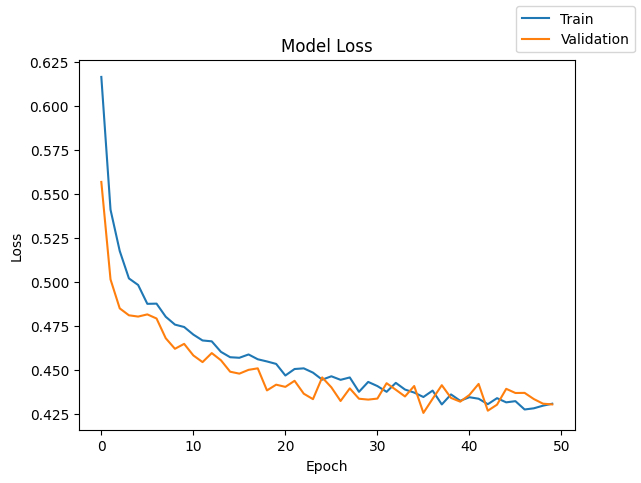

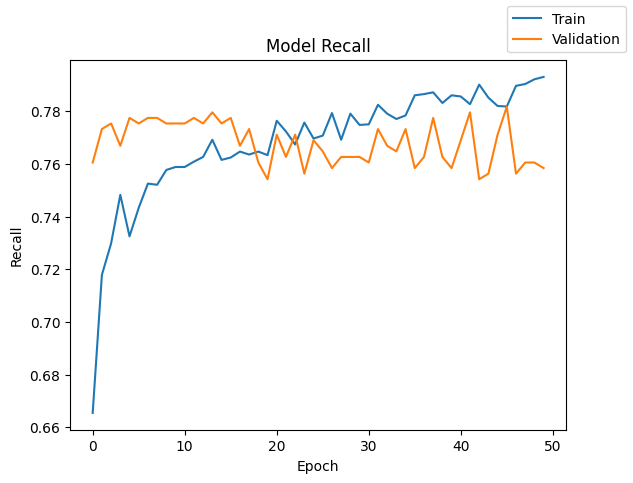

In [240]:
# Plot Training & Validation - Recall & Loss

plot(nn_model_train,'loss')
plot(nn_model_train,'recall')

In [241]:
results.loc[5] = [2,[32, 64],['relu', 'tanh'],50,32,"adam",[0.001, "-"],"xavier","smote, dropout(0.3)",nn_model_train.history["loss"][-1],nn_model_train.history["val_loss"][-1],nn_model_train.history["recall"][-1],nn_model_train.history["val_recall"][-1],round(end_time - start_time,2)]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.436820,0.420412,0.133851,0.105932,35.84
1,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,-,0.316814,0.323157,0.512953,0.550847,38.33
2,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,dropout (0.3),0.345733,0.319666,0.474093,0.470339,36.53
3,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,smote,0.515850,0.522986,0.761144,0.747881,56.51
4,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,smote,0.352372,0.441176,0.851643,0.709746,63.09
5,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,"smote, dropout(0.3)",0.430896,0.430508,0.793111,0.758475,63.62


### Observations ###
- In this model because of drop-outs the gradients are 'choppy' for both Training & Validation sets.
- Loss function Validation follows the same gradient as Training and they are tending towards convergance.
- Recall Value is for Training & Validation is consideraly higher, convergance between Trainign & Validation happen very early in the Epoch.
- Gradient of both is diverging right after convergance, which says that neural network is overfitting and understand og learnign data compared to tranign data has not happend properly in the network.

## Model Performance Comparison and Final Model Selection

In [242]:
# Consolidate Result
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,-,0.436820,0.420412,0.133851,0.105932,35.84
1,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,-,0.316814,0.323157,0.512953,0.550847,38.33
2,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,dropout (0.3),0.345733,0.319666,0.474093,0.470339,36.53
3,2,"[32, 64]","[relu, tanh]",50,32,sgd,"[0.001, -]",xavier,smote,0.515850,0.522986,0.761144,0.747881,56.51
4,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,smote,0.352372,0.441176,0.851643,0.709746,63.09
5,2,"[32, 64]","[relu, tanh]",50,32,adam,"[0.001, -]",xavier,"smote, dropout(0.3)",0.430896,0.430508,0.793111,0.758475,63.62


### Model Selection & Reason
- From the above result we can see that we have held several of the Model Selection Parameters in steady state acorss all the test cases.
- This is maily to compare all the cases in an even manner.
- By tuning several of the paramters in various combinations, we could potentially get better results.

- ***Under the current curcumstances we have choosen Mode 4 - SDG with SMOTE***
  - This has high Recall ~75% for both Training & Validation
  - Loss funcation is around 50% for Training & Validation
  - Smoother Gradient and Loss Functions Values were very close through all Epochs, which tells neural network was well trained to predict Validation data from Training data.  
  - It has fairly good Execution time ~50sec (compared to larger time models)

Other Models (few of them) gave high Recall but the data sets between Training & Validation were getting into OverFittign mode at a very early stages of Epochs, and were running a higher Compute Time and Varying Loss values.   

In [243]:
# Running the Prediction on Evaluation dataset on the selected Model
# Finding Recall between Evaluation Actual & Predicted

y_eval1_pred = nn_model_4.predict(X_eval1)
y_eval1_pred = (y_eval1_pred > 0.5)

print("Recall Score:", recall_score(y_eval1, y_eval1_pred))

score_report=classification_report(y_eval1,y_eval1_pred)
print(score_report)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Recall Score: 0.7371007371007371
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1593
           1       0.44      0.74      0.55       407

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75      0.77      2000



### Observation ###
- Recall Score in Prediction on Evaluation data is in line with Model-4 Recall Score on Validation data = 0.737
- Hence this Model can be considered well Trained Neural Network Model

## Actionable Insights and Business Recommendations

- We have create a Model (SGD with SMOTE) that will help predict with ~75% confidence on People Exists.
- In future this model could be further tuned to improve Recall Score.
- Some of the observations from data sets are -
  - Age, Balance, Estimated Salary, German Geography have hih correlation with Exits.
  - Higher degree of people Existed from German Geography. We need to see if this trend can be reversed.
  - Age is also observed as a factor where middle age people (30, 40, 50) are seen to exit the bank more. Sothis need to be addressed.
  - On the Estimated Salary, numbers are evenly split between people leavg and stayng around 100,000 mark of Salary.
  - High Salary group & low Salary group are majority of people staying.
  - There are several data points wehre Balance is found to be Zero. Knowing this data probaly could help improve prediction better for our models.


